In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib.image import imread

In [2]:
from tensorflow.keras.models import load_model
model = load_model('latest_model.h5')
#model = load_model('efficentnetv2-s.h5')

In [3]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 64, 64, 64)       256       
 hNormalization)                                                 
                                                        

In [4]:
import tensorflow as tf
import cv2
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#def add_gaussian_blur(img):
#    img = img.astype(np.uint8)  
#    blurred = cv2.GaussianBlur(img, (5, 5), 0)
#    return blurred.astype('float32')


train_datagen = ImageDataGenerator(#preprocessing_function=add_gaussian_blur,
    rescale=1./255,
    #rotation_range=20,
    #width_shift_range=0.2,
    #height_shift_range=0.2,
    #zoom_range=0.2,
    #horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2  # 20% for validation
)



train_generator = train_datagen.flow_from_directory(
    "C:\\Users\\Yashas\\downloads\\Sugarcane_leafs",  # change to your dataset path
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    "C:\\Users\\Yashas\\downloads\\Sugarcane_leafs",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 14477 images belonging to 6 classes.
Found 3616 images belonging to 6 classes.


In [5]:
heal_cell = 'C:\\Users\\Yashas\\vehan6.jpg'
heal_img= imread(heal_cell)

In [6]:
#plt.imshow(heal_img)

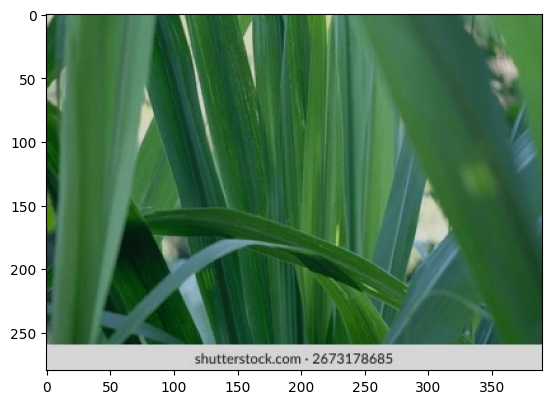

In [7]:
plt.imshow(train_datagen.random_transform(heal_img).astype(np.uint8))

In [3]:
model.evaluate(val_ds)

114/114 [==============================] - 8s 66ms/step - loss: 0.2071 - accuracy: 0.9331


[0.20706315338611603, 0.9331122040748596]

In [4]:
from tensorflow.keras.preprocessing import image

In [5]:
pred_probabilities = model.predict(val_ds)

114/114 [==============================] - 10s 64ms/step


In [6]:
predictions = (pred_probabilities > 0.5).astype(int).argmax(axis=1)

In [7]:
predictions

array([1, 4, 4, ..., 0, 0, 1], dtype=int64)

In [8]:
from sklearn.metrics import classification_report,confusion_matrix

In [9]:
true_labels = []
for images, labels in val_ds:
    true_labels.extend(np.argmax(labels.numpy(), axis=1))
true_labels = np.array(true_labels)

In [10]:
print(confusion_matrix(true_labels,predictions))
print(classification_report(true_labels,predictions))

[[109  99  91  99  89  90]
 [112  94  84 123 112  85]
 [100 102  83 100  99  89]
 [107 117  88  98 110 100]
 [111 117  75 106  99  95]
 [109 120  99 103 101 103]]
              precision    recall  f1-score   support

           0       0.17      0.19      0.18       577
           1       0.14      0.15      0.15       610
           2       0.16      0.14      0.15       573
           3       0.16      0.16      0.16       620
           4       0.16      0.16      0.16       603
           5       0.18      0.16      0.17       635

    accuracy                           0.16      3618
   macro avg       0.16      0.16      0.16      3618
weighted avg       0.16      0.16      0.16      3618



In [6]:
#Latest_model:

In [15]:
print(confusion_matrix(val_generator.classes,predictions))
print(classification_report(val_generator.classes,predictions))

[[ 95 114  84 101 114  85]
 [108 106  94 101  96 121]
 [ 85  94  95  87 108  85]
 [ 92 108  94 127 107  93]
 [108 104  87 109 114  94]
 [120 111  92  94 104  85]]
              precision    recall  f1-score   support

           0       0.16      0.16      0.16       593
           1       0.17      0.17      0.17       626
           2       0.17      0.17      0.17       554
           3       0.21      0.20      0.20       621
           4       0.18      0.19      0.18       616
           5       0.15      0.14      0.15       606

    accuracy                           0.17      3616
   macro avg       0.17      0.17      0.17      3616
weighted avg       0.17      0.17      0.17      3616



In [11]:
my_image = image.load_img('C:\\Users\\Yashas\\img9.jpg',target_size=(224,224,3))

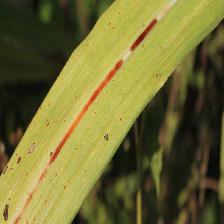

In [12]:
my_image

In [13]:
my_image = image.img_to_array(my_image)

In [14]:
my_image = np.expand_dims(my_image, axis=0)

In [15]:
my_image.shape

(1, 224, 224, 3)

In [16]:
pred=model.predict(my_image)

1/1 [==============================] - 3s 3s/step


In [17]:
class_idx = np.argmax(pred)
print("Predicted class:", class_idx)

Predicted class: 4


In [18]:
pred

array([[6.2713921e-02, 8.2709848e-05, 1.3585188e-04, 1.7816411e-01,
        5.2203023e-01, 2.3687315e-01]], dtype=float32)

In [19]:
train_generator.class_indices

NameError: name 'train_generator' is not defined

In [20]:
label_dict = {0:'BacterialBlights',
1:'Healthy',
2:'Mosaic',
3:'RedRot',
4:'Rust',
5:'Yellow'}

In [21]:
solution_dict = {
    0: 'Use copper-based bactericides; avoid water stagnation and practice crop rotation.',
    1: 'No treatment needed; maintain proper irrigation and regular crop monitoring.',
    2: 'Control aphid vectors with neem oil or systemic insecticides; rogue out infected plants.',
    3: 'Remove and burn infected clumps; apply fungicides like carbendazim or triazoles.',
    4: 'Spray fungicides containing mancozeb or propiconazole; improve field drainage and spacing.',
    5: 'Apply balanced fertilizers with adequate nitrogen; foliar spray with zinc or iron if deficiency symptoms persist.'
}


In [28]:
def solution(img):
    pred = model.predict(img)
    pred_sorted = pred.argsort(axis=1)
    top3_indices = pred_sorted[0, -1:-4:-1]  
    top3_labels = [label_dict[i] for i in top3_indices] 
    top3_answers = [solution_dict[i] for i in top3_indices]
    if top3_labels[0] == 'Healthy':
        pred_sorted = pred.argsort(axis=1)
        top3_indices = pred_sorted[0, -1:-4:-1]  
    else:
        print(f"The Sugarcane leaf is infected by {top3_labels[0]}, "
              f"{top3_labels[1]} "
              f"{top3_labels[2]}")
        print(f"Solution:{top3_answers[0]} "
              f"{top3_answers[1]} ")
    val_loss, val_acc = model.evaluate(val_ds,verbose=0)
    print(f"Confidence Rate: {val_acc*100:.2f}")
    

In [29]:
solution(my_image)

1/1 [==============================] - 0s 52ms/step
The Sugarcane leaf is infected by Rust, Yellow RedRot
Solution:Spray fungicides containing mancozeb or propiconazole; improve field drainage and spacing. Apply balanced fertilizers with adequate nitrogen; foliar spray with zinc or iron if deficiency symptoms persist. 
Confidence Rate: 93.31


In [49]:
pred = model.predict(my_image)
pred_sorted = pred.argsort(axis=1)
top3_indices = pred_sorted[0, -1:-4:-1] 

1/1 [==============================] - 0s 49ms/step


In [50]:
top3_indices

array([0, 5, 4], dtype=int64)

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



train_datagen = ImageDataGenerator(
    rescale=1./255,
    #rotation_range=20,
    #width_shift_range=0.2,
    #height_shift_range=0.2,
    #zoom_range=0.2,
    #horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2  # 20% for validation
)



train_generator = train_datagen.flow_from_directory(
    "C:\\Users\\Yashas\\downloads\\Sugarcane_leafs",  # change to your dataset path
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    "C:\\Users\\Yashas\\downloads\\Sugarcane_leafs",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)


model = models.Sequential([
    layers.Conv2D(32/8, (1,1), activation='relu', padding='same', input_shape=(128,128,3),
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64/8, (1,1), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128/8, (1,1), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256/8, (1,1), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    
    
    

    

    layers.GlobalAveragePooling2D(),

    
    layers.Dense(2048/8, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    
    
    
    layers.Dense(train_generator.num_classes, activation='softmax')
])


lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, lr_scheduler]
)


val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc:.2f}")


Found 14477 images belonging to 6 classes.
Found 3616 images belonging to 6 classes.
Epoch 1/10
453/453 [==============================] - 118s 256ms/step - loss: 1.5603 - accuracy: 0.4138 - val_loss: 1.3862 - val_accuracy: 0.5080 - lr: 5.0000e-04
Epoch 2/10
 69/453 [===>..........................] - ETA: 1:18 - loss: 1.3552 - accuracy: 0.5162

KeyboardInterrupt: 

In [17]:
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_39 (Conv2D)          (None, 128, 128, 4)       16        
                                                                 
 batch_normalization_39 (Bat  (None, 128, 128, 4)      16        
 chNormalization)                                                
                                                                 
 max_pooling2d_39 (MaxPoolin  (None, 64, 64, 4)        0         
 g2D)                                                            
                                                                 
 conv2d_40 (Conv2D)          (None, 64, 64, 8)         40        
                                                                 
 batch_normalization_40 (Bat  (None, 64, 64, 8)        32        
 chNormalization)                                                
                                                      

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, applications

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

img_size = (224,224)
batch_size = 32
num_classes = 6


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "C:\\Users\\Yashas\\downloads\\Sugarcane_leafs", label_mode='categorical', image_size=img_size, batch_size=batch_size, validation_split=0.2, subset='training', seed=42)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "C:\\Users\\Yashas\\downloads\\Sugarcane_leafs", label_mode='categorical', image_size=img_size, batch_size=batch_size, validation_split=0.2, subset='validation', seed=42)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "C:\\Users\\Yashas\\downloads\\Sugarcane_leafs", label_mode='categorical', image_size=img_size, batch_size=batch_size)

# Prefetch/augment
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1024).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.08,0.08),
])

base = applications.EfficientNetB0(include_top=False, input_shape=(*img_size,3), pooling='avg', weights='imagenet')
base.trainable = False

inputs = layers.Input(shape=(*img_size,3))
x = data_augmentation(inputs)
x = applications.efficientnet.preprocess_input(x)
x = base(x, training=False)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer=optimizers.Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

cb = [
    callbacks.ModelCheckpoint('best.h5', save_best_only=True, monitor='val_loss'),
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss',factor=float(0.5),patience=int(3),min_lr=float(1e-7))
]

# Stage 1
model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=cb)

# Stage 2: fine-tune
base.trainable = True
# Optionally freeze lower layers:
# for layer in base.layers[:200]: layer.trainable = False

model.compile(optimizer=optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=cb)


Found 18093 files belonging to 6 classes.
Using 14475 files for training.
Found 18093 files belonging to 6 classes.
Using 3618 files for validation.
Found 18093 files belonging to 6 classes.
Epoch 1/10
453/453 [==============================] - ETA: 0s - loss: 0.8213 - accuracy: 0.7077

TypeError: Unable to serialize [2.0896919 2.1128857 2.1081853] to JSON. Unrecognized type <class 'tensorflow.python.framework.ops.EagerTensor'>.

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


img_size = (224, 224)
num_classes = 6
batch_size = 32


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "C:\\Users\\Yashas\\downloads\\Sugarcane_leafs",
    label_mode='categorical',
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=42
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "C:\\Users\\Yashas\\downloads\\Sugarcane_leafs",
    label_mode='categorical',
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=42
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.08, 0.08),
])


base = applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(*img_size, 3),
    pooling='avg'
)
base.trainable = False  # Stage 1: freeze backbone

# -----------------------------
# Model head
# -----------------------------
inputs = layers.Input(shape=(*img_size, 3))
x = data_augmentation(inputs)
x = applications.efficientnet.preprocess_input(x)
x = base(x, training=False)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)


cb = [
    #callbacks.ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss'),
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]


model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=cb
)


base.trainable = True  


model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=cb
)


Found 18093 files belonging to 6 classes.
Using 14475 files for training.
Found 18093 files belonging to 6 classes.
Using 3618 files for validation.
Epoch 1/10
453/453 [==============================] - 285s 591ms/step - loss: 0.8190 - accuracy: 0.7110 - val_loss: 0.5874 - val_accuracy: 0.7811 - lr: 0.0010
Epoch 2/10
453/453 [==============================] - 263s 579ms/step - loss: 0.6042 - accuracy: 0.7787 - val_loss: 0.5183 - val_accuracy: 0.8226 - lr: 0.0010
Epoch 3/10
453/453 [==============================] - 264s 582ms/step - loss: 0.5424 - accuracy: 0.7990 - val_loss: 0.4951 - val_accuracy: 0.8143 - lr: 0.0010
Epoch 4/10
453/453 [==============================] - 285s 628ms/step - loss: 0.5243 - accuracy: 0.8034 - val_loss: 0.4543 - val_accuracy: 0.8336 - lr: 0.0010
Epoch 5/10
453/453 [==============================] - 291s 641ms/step - loss: 0.4968 - accuracy: 0.8147 - val_loss: 0.4483 - val_accuracy: 0.8336 - lr: 0.0010
Epoch 6/10
453/453 [==============================] - 30

In [39]:
model.save_weights("dominator.h5")

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


img_size = (224, 224)
num_classes = 6
batch_size = 32


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "C:\\Users\\Yashas\\downloads\\Sugarcane_leafs",
    label_mode='categorical',
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=42
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "C:\\Users\\Yashas\\downloads\\Sugarcane_leafs",
    label_mode='categorical',
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=42
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.08, 0.08),
])


base = applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(*img_size, 3),
    pooling='avg'
)
base.trainable = False  # Stage 1: freeze backbone

# -----------------------------
# Model head
# -----------------------------
inputs = layers.Input(shape=(*img_size, 3))
x = data_augmentation(inputs)
x = applications.efficientnet.preprocess_input(x)
x = base(x, training=False)
x = layers.Dropout(0.3)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)


cb = [
    #callbacks.ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss'),
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]


model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=cb
)


base.trainable = True  


model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=cb
)


Found 18093 files belonging to 6 classes.
Using 14475 files for training.
Found 18093 files belonging to 6 classes.
Using 3618 files for validation.
Epoch 1/20
453/453 [==============================] - 270s 546ms/step - loss: 0.8206 - accuracy: 0.7175 - val_loss: 0.5362 - val_accuracy: 0.8024 - lr: 0.0010
Epoch 2/20
453/453 [==============================] - 246s 541ms/step - loss: 0.5936 - accuracy: 0.7827 - val_loss: 0.5102 - val_accuracy: 0.8126 - lr: 0.0010
Epoch 3/20
453/453 [==============================] - 244s 538ms/step - loss: 0.5508 - accuracy: 0.7985 - val_loss: 0.4988 - val_accuracy: 0.8198 - lr: 0.0010
Epoch 4/20
453/453 [==============================] - 245s 541ms/step - loss: 0.5167 - accuracy: 0.8117 - val_loss: 0.4778 - val_accuracy: 0.8347 - lr: 0.0010
Epoch 5/20
453/453 [==============================] - 245s 540ms/step - loss: 0.4883 - accuracy: 0.8183 - val_loss: 0.4439 - val_accuracy: 0.8344 - lr: 0.0010
Epoch 6/20
453/453 [==============================] - 24

In [1]:
#model = model.load_weights

In [2]:
lst=[1,2,3,4]

In [3]:
np.array(lst)

array([1, 2, 3, 4])

In [4]:
loss=np.array([0.8206,0.5936,0.5508,0.5167,0.4883,0.4743,0.4551,0.4373,0.4305,0.4183,0.4031,0.3960,0.3844,0.3805,0.3690,0.3674,0.3304,0.3202,0.3100,0.3055,0.2487,0.2066,0.1853,0.1654,0.1528,0.1497,0.1386,0.1376,0.1245,0.1228,0.1134,0.1120,0.1021,0.1017,0.0975,0.0972,0.0882,0.0880,0.0808,0.0793,0.0746,0.0780,0.0707,0.0668,0.0628,0.0650,0.0620,0.0591,0.0579])

In [5]:
val_loss =np.array([0.5362,0.5102,0.4988,0.4778,0.4439,0.4652,0.4731,0.4278,0.4317,0.4417,0.4086,0.4437,0.3908,0.4206,0.4043,0.4096,0.3530,0.3890,0.3397,0.3695,0.3143,0.3093,0.2928,0.2849,0.2621,0.2763,0.2574,0.2624,0.2647,0.2554,0.2438,0.2521,0.2421,0.2317,0.2473,0.2353,0.2285,0.2399,0.2334,0.2229,0.2071,0.2122,0.2189,0.2125,0.2240,0.2222,0.2151,0.2161,0.2162])

In [6]:
losses = pd.DataFrame({'Loss':loss,'Val_loss':val_loss})

In [7]:
len(val_loss)

49

<Axes: >

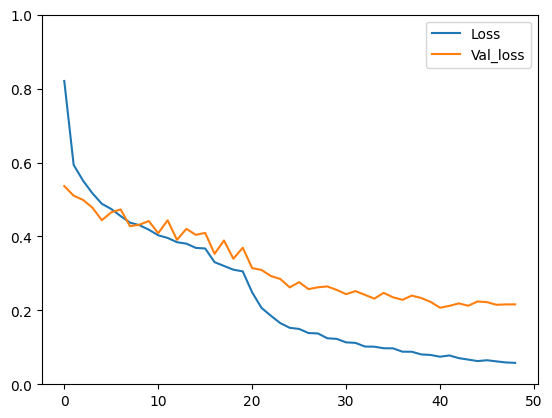

In [15]:
losses.plot(ylim=(0,1))